In [1]:
# Import libraries

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
# Create 300 simulated farm plots
# Each farm has two features

X, _ = make_blobs(
    n_samples=300,
    centers=4,
    cluster_std=2.5,
    random_state=42
)

print("Number of farms:", X.shape[0])
print("Number of features:", X.shape[1])
print("\nFirst 5 farms:")
print(X[:5])

Number of farms: 300
Number of features: 2

First 5 farms:
[[ -9.98673001   5.19891199]
 [-10.98936117   6.36213405]
 [ -0.45283534   5.962177  ]
 [ -7.4238302   -4.13316746]
 [-13.93363909   4.80330714]]


In [3]:
# Create the K-means model

model = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

# Discover the groups

labels = model.fit_predict(X)

# Get the center of each group

centers = model.cluster_centers_

print("K-means clustering complete!")
print("Number of clusters:", len(centers))

K-means clustering complete!
Number of clusters: 4


In [4]:
# Show the first 10 farm assignments

print("First 10 farm cluster assignments:")
print(labels[:10])

print("\nCluster centers:")
print(centers)

First 10 farm cluster assignments:
[2 2 3 1 2 1 0 1 3 0]

Cluster centers:
[[ 4.94770283  1.95922932]
 [-6.71804263 -6.67481906]
 [-8.96104165  6.83509679]
 [-2.4859672   9.14181565]]


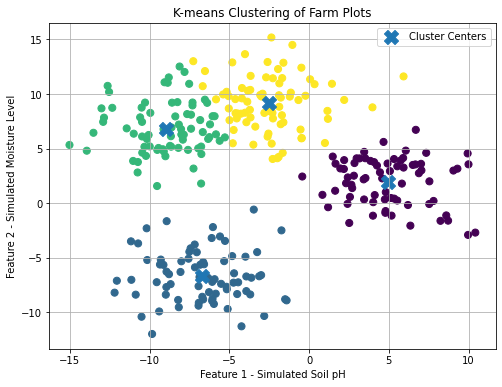

In [5]:
# Visualize the discovered farm groups

plt.figure(figsize=(8, 6))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=labels,
    cmap="viridis",
    s=50
)

# Show the cluster centers

plt.scatter(
    centers[:, 0],
    centers[:, 1],
    marker="X",
    s=200,
    label="Cluster Centers"
)

plt.title("K-means Clustering of Farm Plots")
plt.xlabel("Feature 1 - Simulated Soil pH")
plt.ylabel("Feature 2 - Simulated Moisture Level")

plt.legend()
plt.grid(True)
plt.show()

In [6]:
# Evaluate how well separated the clusters are

score = silhouette_score(X, labels)

print("Silhouette Score:")
print(round(score, 3))

Silhouette Score:
0.53


In [7]:
# Create a new farm observation

new_farm = np.array([[5.0, 3.0]])

# Determine which cluster it belongs to

new_cluster = model.predict(new_farm)

print("New farm belongs to cluster:")
print(new_cluster[0])

New farm belongs to cluster:
0
